In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../datasets/team_performance_dataset_2008to2024.csv')
df.head()

,Match_ID,Date,Teams,Venue,Toss_Winner,Toss_Decision,Match_Winner,Win_Type,Win_Margin,First_Innings_Score,Second_Innings_Score,Player_of_Match,Umpire,Umpire1,Umpire2,Powerplay_Scores,Middle_Overs_Scores,Death_Overs_Scores
0,335982,2008-04-18,Royal Challengers Bangalore vs Kolkata Knight ...,M Chinnaswamy Stadium,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,222,82.0,BB McCullum,Asad Rauf,RE Koertzen,J Srinath,61,97,64
1,335983,2008-04-19,Kings XI Punjab vs Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,240,207.0,MEK Hussey,MR Benson,SL Shastri,S Venkataraghavan,53,116,71
2,335984,2008-04-19,Delhi Daredevils vs Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,129,132.0,MF Maharoof,Aleem Dar,GA Pratapkumar,GR Viswanath,40,66,23
3,335985,2008-04-20,Mumbai Indians vs Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,165,166.0,MV Boucher,SJ Davis,DJ Harper,J Srinath,47,71,47
4,335986,2008-04-20,Kolkata Knight Riders vs Deccan Chargers,Eden Gardens,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,110,112.0,DJ Hussey,BF Bowden,K Hariharan,FM Engineer,39,43,28


In [3]:
print("\nDataset Size:", df.size)


Dataset Size: 19314


In [4]:

print("\nColumn Information:\n", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1073 entries, 0 to 1072
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Match_ID              1073 non-null   int64  
 1   Date                  1073 non-null   object 
 2   Teams                 1073 non-null   object 
 3   Venue                 1073 non-null   object 
 4   Toss_Winner           1073 non-null   object 
 5   Toss_Decision         1073 non-null   object 
 6   Match_Winner          1073 non-null   object 
 7   Win_Type              1054 non-null   object 
 8   Win_Margin            1054 non-null   float64
 9   First_Innings_Score   1073 non-null   int64  
 10  Second_Innings_Score  1070 non-null   float64
 11  Player_of_Match       1068 non-null   object 
 12  Umpire                1073 non-null   object 
 13  Umpire1               1073 non-null   object 
 14  Umpire2               1073 non-null   object 
 15  Powerplay_Scores     

In [5]:

print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 Match_ID                 0
Date                     0
Teams                    0
Venue                    0
Toss_Winner              0
Toss_Decision            0
Match_Winner             0
Win_Type                19
Win_Margin              19
First_Innings_Score      0
Second_Innings_Score     3
Player_of_Match          5
Umpire                   0
Umpire1                  0
Umpire2                  0
Powerplay_Scores         0
Middle_Overs_Scores      0
Death_Overs_Scores       0
dtype: int64


In [6]:

print("\nBasic Statistics:\n", df.describe())


Basic Statistics:
            Match_ID   Win_Margin  First_Innings_Score  Second_Innings_Score  \
count  1.073000e+03  1054.000000          1073.000000           1070.000000   
mean   8.941365e+05    17.158444           165.164958            151.918692   
std    3.637486e+05    21.762303            31.904238             31.751666   
min    3.359820e+05     1.000000            56.000000              2.000000   
25%    5.483260e+05     6.000000           145.000000            134.000000   
50%    9.809390e+05     8.000000           165.000000            153.000000   
75%    1.216540e+06    19.750000           186.000000            172.000000   
max    1.426287e+06   146.000000           287.000000            262.000000   

       Powerplay_Scores  Middle_Overs_Scores  Death_Overs_Scores  
count       1073.000000          1073.000000         1073.000000  
mean          46.074557            78.248835           40.841566  
std           12.007306            18.604148           14.228121  


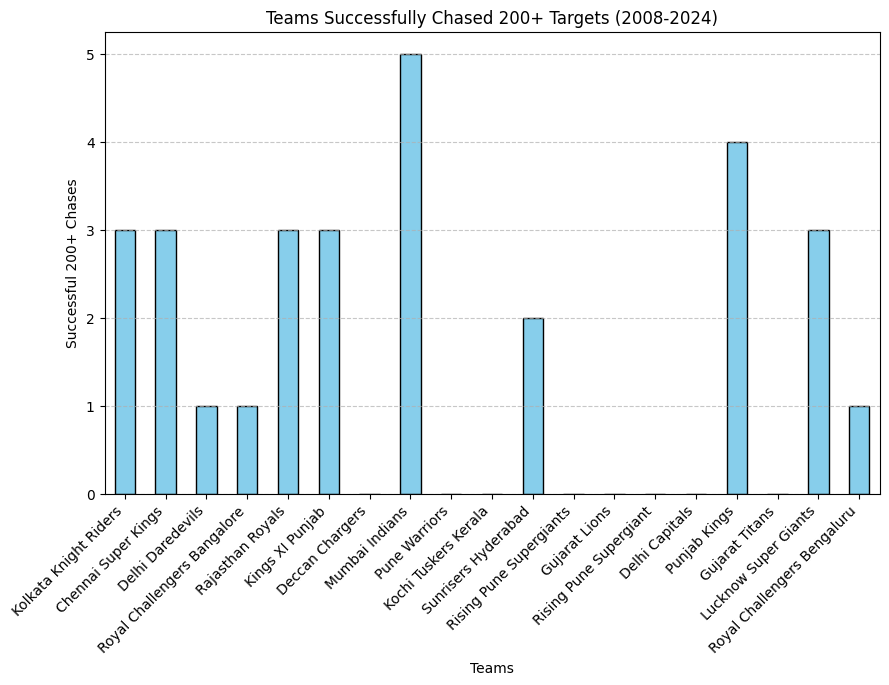

Match_Winner
Kolkata Knight Riders          3
Chennai Super Kings            3
Delhi Daredevils               1
Royal Challengers Bangalore    1
Rajasthan Royals               3
Kings XI Punjab                3
Deccan Chargers                0
Mumbai Indians                 5
Pune Warriors                  0
Kochi Tuskers Kerala           0
Sunrisers Hyderabad            2
Rising Pune Supergiants        0
Gujarat Lions                  0
Rising Pune Supergiant         0
Delhi Capitals                 0
Punjab Kings                   4
Gujarat Titans                 0
Lucknow Super Giants           3
Royal Challengers Bengaluru    1
Name: count, dtype: int64


In [7]:

chased_200 = df[(df['Second_Innings_Score'] >= 200) & (df['Win_Type'] == 'wickets')]
chased_200_counts = chased_200['Match_Winner'].value_counts()

valid_teams = df['Match_Winner'].unique()
valid_teams = [team for team in valid_teams if team not in ['Draw/No Result']]

chased_200_counts = chased_200_counts.reindex(valid_teams, fill_value=0)

plt.figure(figsize=(10, 6))
chased_200_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Teams')
plt.ylabel('Successful 200+ Chases')
plt.title('Teams Successfully Chased 200+ Targets (2008-2024)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(chased_200_counts)





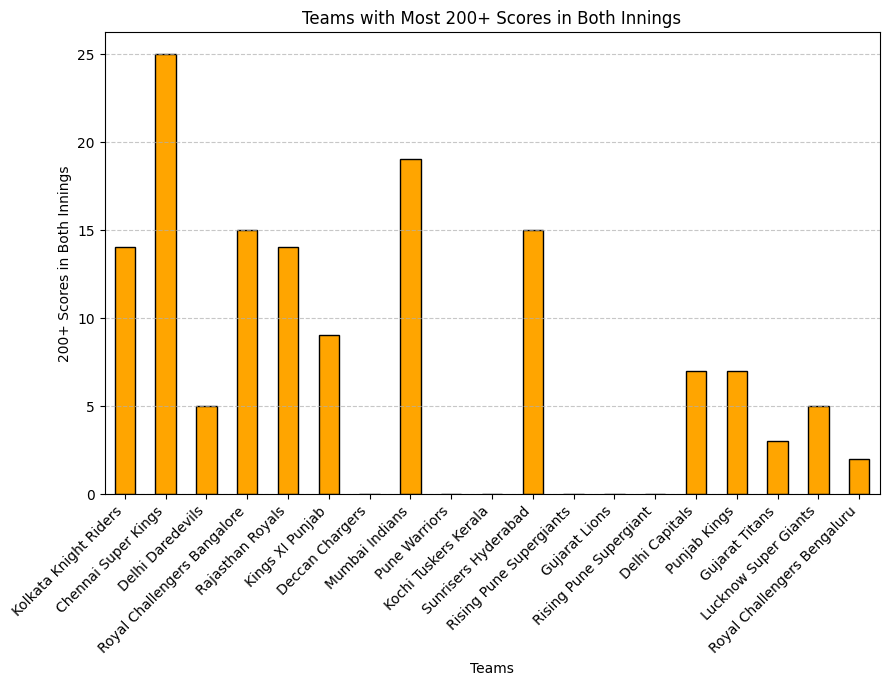

Match_Winner
Kolkata Knight Riders          3
Chennai Super Kings            3
Delhi Daredevils               1
Royal Challengers Bangalore    1
Rajasthan Royals               3
Kings XI Punjab                3
Deccan Chargers                0
Mumbai Indians                 5
Pune Warriors                  0
Kochi Tuskers Kerala           0
Sunrisers Hyderabad            2
Rising Pune Supergiants        0
Gujarat Lions                  0
Rising Pune Supergiant         0
Delhi Capitals                 0
Punjab Kings                   4
Gujarat Titans                 0
Lucknow Super Giants           3
Royal Challengers Bengaluru    1
Name: count, dtype: int64


In [8]:

Most_200 =df[(df['First_Innings_Score'] >= 200) | (df['Second_Innings_Score'] >= 200)]


Most_200_counts = Most_200['Match_Winner'].value_counts()

valid_teams = df['Match_Winner'].unique()
valid_teams = [team for team in valid_teams if team not in ['Draw/No Result']]

Most_200_counts = Most_200_counts.reindex(valid_teams, fill_value=0)

plt.figure(figsize=(10, 6))
Most_200_counts.plot(kind='bar', color='orange', edgecolor='black')
plt.xlabel('Teams')
plt.ylabel('200+ Scores in Both Innings')
plt.title('Teams with Most 200+ Scores in Both Innings')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(chased_200_counts)


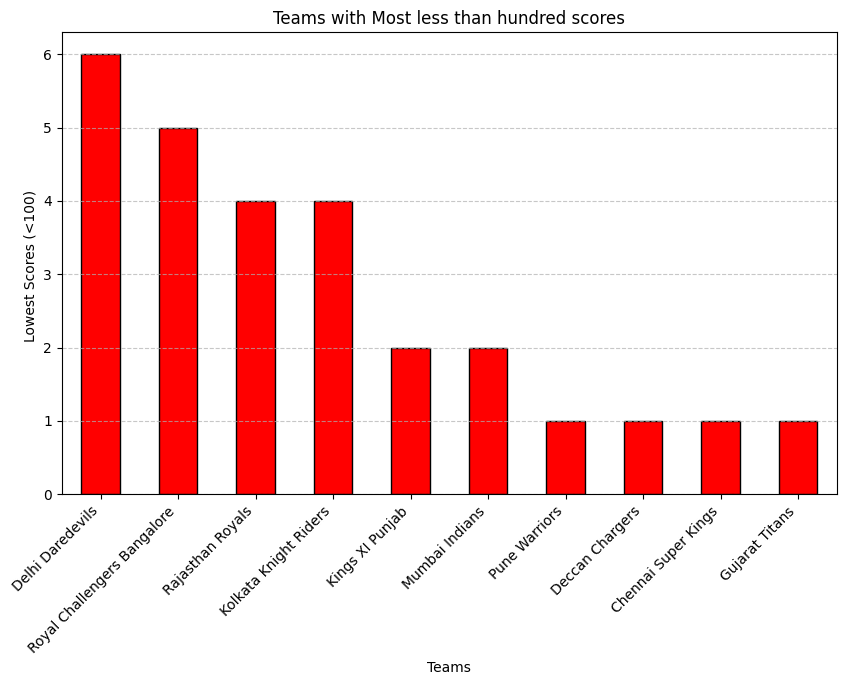

First_Innings_Team
Delhi Daredevils               6
Royal Challengers Bangalore    5
Rajasthan Royals               4
Kolkata Knight Riders          4
Kings XI Punjab                2
Mumbai Indians                 2
Pune Warriors                  1
Deccan Chargers                1
Chennai Super Kings            1
Gujarat Titans                 1
Name: count, dtype: int64


In [9]:

def get_first_innings_team(row):
    team1, team2 = row["Teams"].split(" vs ")
    return row["Toss_Winner"] if row["Toss_Decision"] == "bat" else (team2 if row["Toss_Winner"] == team1 else team1)

df["First_Innings_Team"] = df.apply(get_first_innings_team, axis=1)

low_scores_first_innings = df[df['First_Innings_Score'] < 100]

low_scores_counts_first_innings = low_scores_first_innings['First_Innings_Team'].value_counts()

plt.figure(figsize=(10, 6))
low_scores_counts_first_innings.plot(kind='bar', color='red', edgecolor='black')
plt.xlabel('Teams')
plt.ylabel('Lowest Scores (<100) ')
plt.title('Teams with Most less than hundred scores')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(low_scores_counts_first_innings)


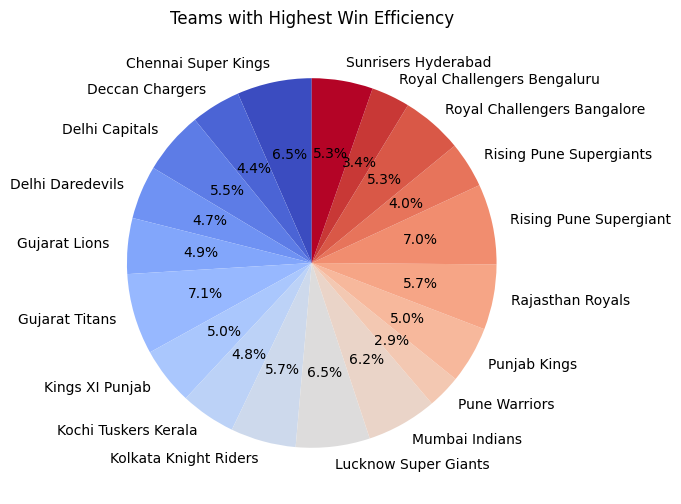

Chennai Super Kings            58.119658
Deccan Chargers                38.666667
Delhi Capitals                 48.863636
Delhi Daredevils               41.614907
Gujarat Lions                  43.333333
Gujarat Titans                 62.790698
Kings XI Punjab                44.736842
Kochi Tuskers Kerala           42.857143
Kolkata Knight Riders          50.813008
Lucknow Super Giants           57.500000
Mumbai Indians                 54.863813
Pune Warriors                  26.086957
Punjab Kings                   44.230769
Rajasthan Royals               50.697674
Rising Pune Supergiant         62.500000
Rising Pune Supergiants        35.714286
Royal Challengers Bangalore    47.500000
Royal Challengers Bengaluru    30.000000
Sunrisers Hyderabad            47.428571
dtype: float64


In [10]:

all_teams = set(df['Teams'].str.split(' vs ').sum())

total_matches = {team: 0 for team in all_teams}

for match in df['Teams']:
    team1, team2 = match.split(' vs ')
    total_matches[team1] += 1
    total_matches[team2] += 1

total_matches = pd.Series(total_matches)

wins = df['Match_Winner'].value_counts()

win_efficiency = (wins / total_matches) * 100

win_efficiency = win_efficiency.dropna()

plt.figure(figsize=(10, 6))
win_efficiency.plot(kind='pie', autopct='%1.1f%%', cmap='coolwarm', startangle=90)
plt.ylabel('') 
plt.title('Teams with Highest Win Efficiency')
plt.show()

print(win_efficiency)


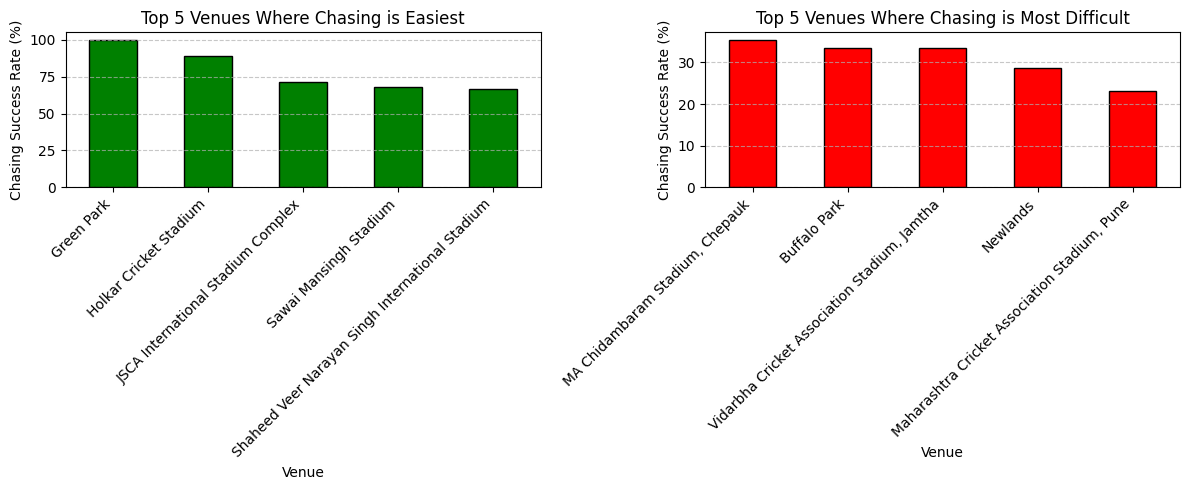

Top venues where chasing is easiest:
Venue
Green Park                                          100.000000
Holkar Cricket Stadium                               88.888889
JSCA International Stadium Complex                   71.428571
Sawai Mansingh Stadium                               68.085106
Shaheed Veer Narayan Singh International Stadium     66.666667
Name: count, dtype: float64

Top venues where chasing is most difficult:
Venue
MA Chidambaram Stadium, Chepauk                  35.416667
Buffalo Park                                     33.333333
Vidarbha Cricket Association Stadium, Jamtha     33.333333
Newlands                                         28.571429
Maharashtra Cricket Association Stadium, Pune    23.076923
Name: count, dtype: float64


In [11]:

chasing_wins = df[df['Win_Type'] == 'wickets']['Venue'].value_counts()

total_matches_per_venue = df['Venue'].value_counts()

chasing_success_rate = (chasing_wins / total_matches_per_venue) * 100

chasing_success_rate = chasing_success_rate.dropna().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)  
chasing_success_rate.head(5).plot(kind='bar', color='green', edgecolor='black')
plt.xlabel('Venue')
plt.ylabel('Chasing Success Rate (%)')
plt.title('Top 5 Venues Where Chasing is Easiest')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.subplot(1, 2, 2)  
chasing_success_rate.tail(5).plot(kind='bar', color='red', edgecolor='black')
plt.xlabel('Venue')
plt.ylabel('Chasing Success Rate (%)')
plt.title('Top 5 Venues Where Chasing is Most Difficult')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show both plots
plt.tight_layout()
plt.show()

print("Top venues where chasing is easiest:")
print(chasing_success_rate.head())

print("\nTop venues where chasing is most difficult:")
print(chasing_success_rate.tail())


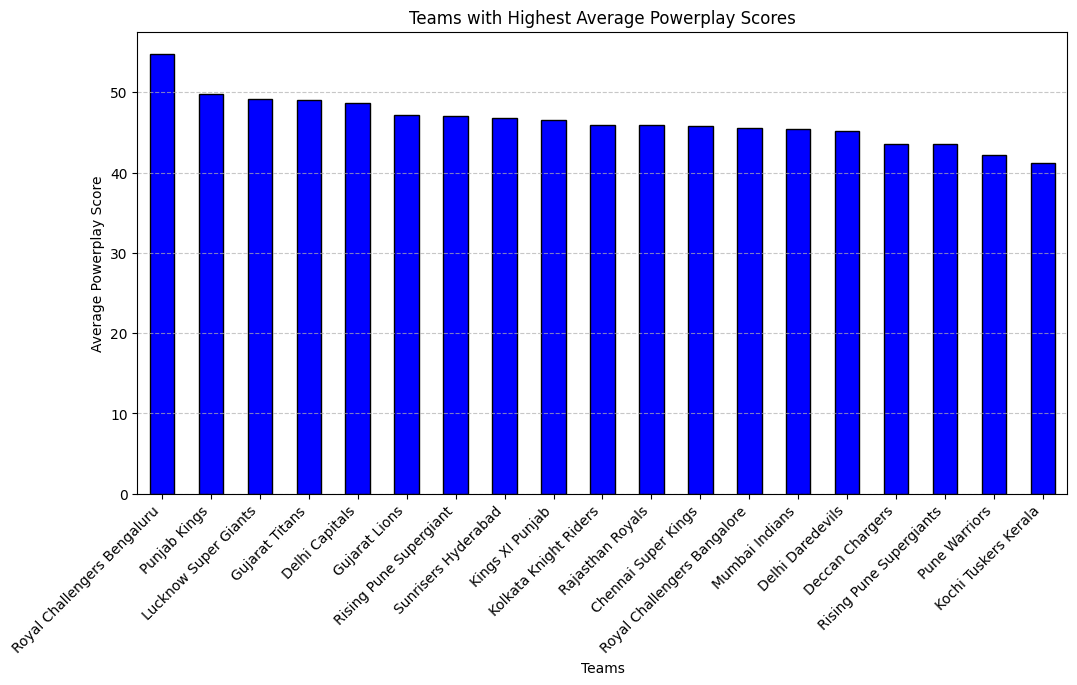

Team
Royal Challengers Bengaluru    54.800000
Punjab Kings                   49.730769
Lucknow Super Giants           49.200000
Gujarat Titans                 49.093023
Delhi Capitals                 48.715909
Gujarat Lions                  47.200000
Rising Pune Supergiant         47.000000
Sunrisers Hyderabad            46.811429
Kings XI Punjab                46.494737
Kolkata Knight Riders          45.983740
Rajasthan Royals               45.976744
Chennai Super Kings            45.786325
Royal Challengers Bangalore    45.608333
Mumbai Indians                 45.385214
Delhi Daredevils               45.136646
Deccan Chargers                43.586667
Rising Pune Supergiants        43.571429
Pune Warriors                  42.152174
Kochi Tuskers Kerala           41.142857
Name: Powerplay_Scores, dtype: float64


In [12]:

df[['Team1', 'Team2']] = df['Teams'].str.split(' vs ', expand=True)

powerplay_df = df.melt(id_vars=['Powerplay_Scores'], value_vars=['Team1', 'Team2'], 
                        var_name='Innings', value_name='Team')

average_powerplay_scores = powerplay_df.groupby('Team')['Powerplay_Scores'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
average_powerplay_scores.plot(kind='bar', color='blue', edgecolor='black')
plt.xlabel('Teams')
plt.ylabel('Average Powerplay Score')
plt.title('Teams with Highest Average Powerplay Scores')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(average_powerplay_scores)


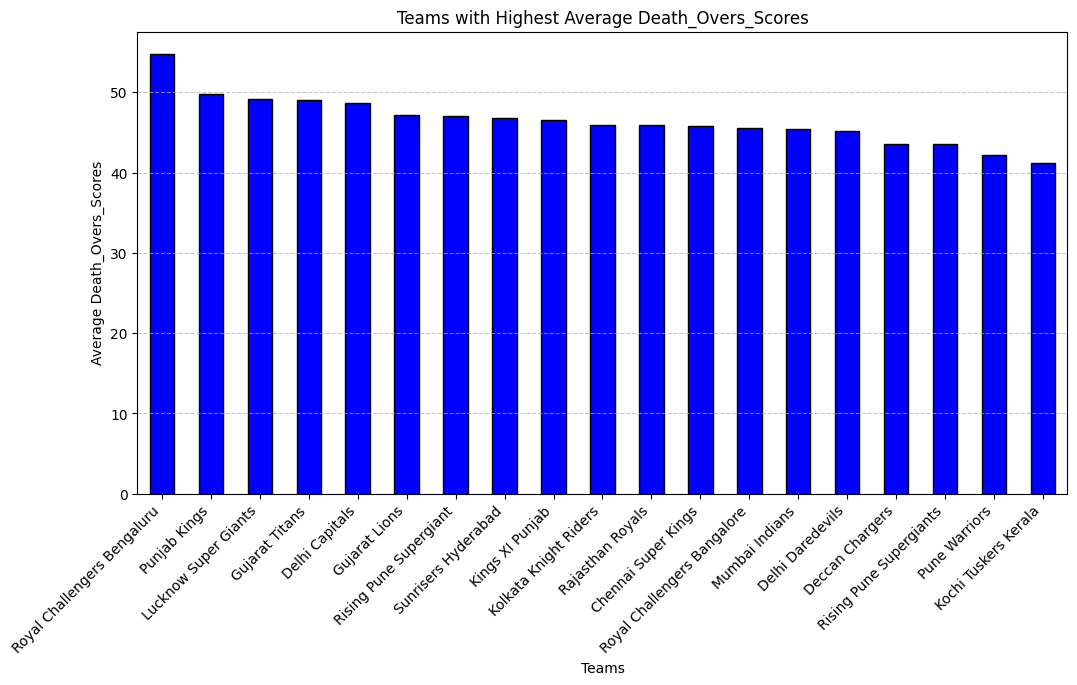

Team
Royal Challengers Bengaluru    50.600000
Lucknow Super Giants           46.000000
Delhi Capitals                 43.886364
Gujarat Titans                 42.883721
Punjab Kings                   42.173077
Chennai Super Kings            42.038462
Mumbai Indians                 41.898833
Deccan Chargers                41.586667
Royal Challengers Bangalore    41.241667
Gujarat Lions                  40.833333
Rising Pune Supergiant         40.625000
Kolkata Knight Riders          40.252033
Sunrisers Hyderabad            39.777143
Rajasthan Royals               39.693023
Delhi Daredevils               39.571429
Rising Pune Supergiants        39.357143
Kings XI Punjab                38.873684
Pune Warriors                  38.521739
Kochi Tuskers Kerala           30.500000
Name: Death_Overs_Scores, dtype: float64


In [13]:

df[['Team1', 'Team2']] = df['Teams'].str.split(' vs ', expand=True)

Death_Overs_Scores_df = df.melt(id_vars=['Death_Overs_Scores'], value_vars=['Team1', 'Team2'], 
                        var_name='Innings', value_name='Team')

average_Death_Overs_Scores = Death_Overs_Scores_df.groupby('Team')['Death_Overs_Scores'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
average_powerplay_scores.plot(kind='bar', color='blue', edgecolor='black')
plt.xlabel('Teams')
plt.ylabel('Average Death_Overs_Scores')
plt.title('Teams with Highest Average Death_Overs_Scores')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(average_Death_Overs_Scores)


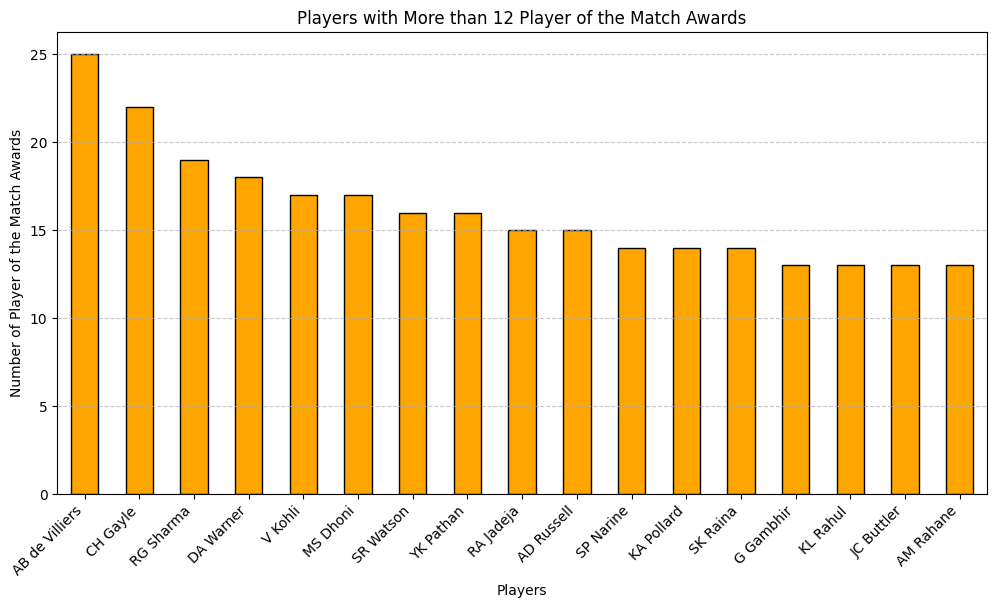

Player_of_Match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
DA Warner         18
V Kohli           17
MS Dhoni          17
SR Watson         16
YK Pathan         16
RA Jadeja         15
AD Russell        15
SP Narine         14
KA Pollard        14
SK Raina          14
G Gambhir         13
KL Rahul          13
JC Buttler        13
AM Rahane         13
Name: count, dtype: int64


In [14]:

player_of_match_counts = df["Player_of_Match"].value_counts()

top_players = player_of_match_counts[player_of_match_counts > 12]

plt.figure(figsize=(12, 6))
top_players.plot(kind='bar', color='orange', edgecolor='black')
plt.xlabel('Players')
plt.ylabel('Number of Player of the Match Awards')
plt.title('Players with More than 12 Player of the Match Awards')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(top_players)


Matches won by toss-winning teams: 544 (50.70%)
Matches lost by toss-winning teams: 529 (49.30%)


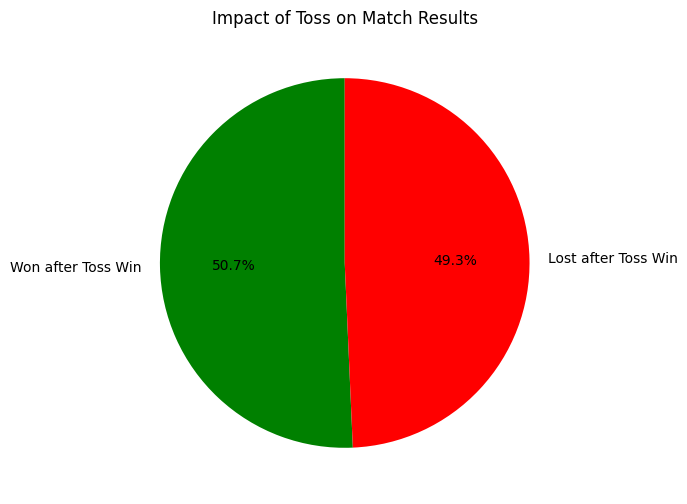

In [15]:

toss_winner_wins = df[df['Toss_Winner'] == df['Match_Winner']].shape[0]

total_matches = df.shape[0]

toss_win_percentage = (toss_winner_wins / total_matches) * 100

print(f"Matches won by toss-winning teams: {toss_winner_wins} ({toss_win_percentage:.2f}%)")
print(f"Matches lost by toss-winning teams: {total_matches - toss_winner_wins} ({100 - toss_win_percentage:.2f}%)")

labels = ['Won after Toss Win', 'Lost after Toss Win']
sizes = [toss_winner_wins, total_matches - toss_winner_wins]
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
plt.title("Impact of Toss on Match Results")
plt.show()


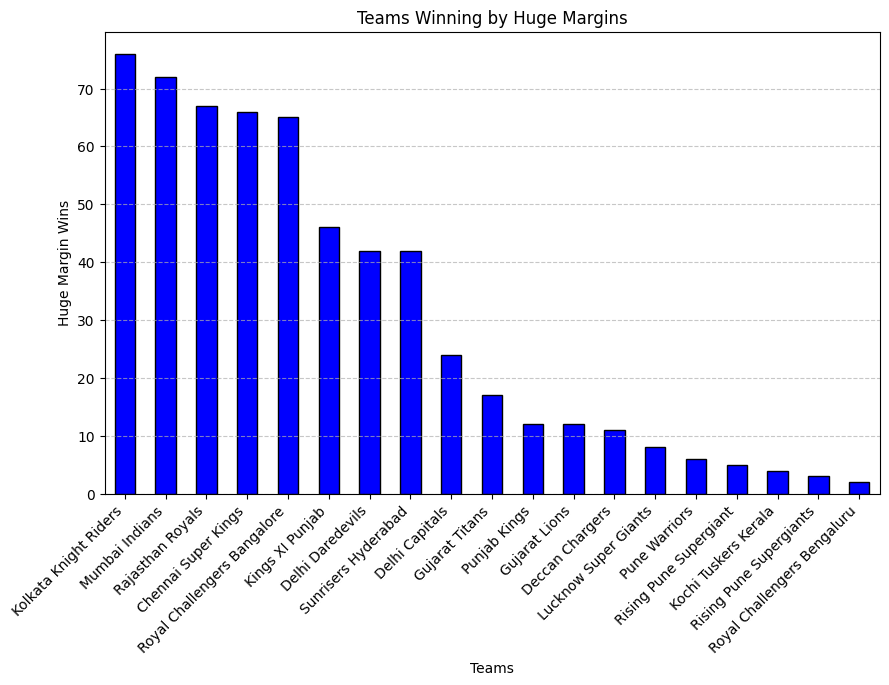

Match_Winner
Kolkata Knight Riders          76
Mumbai Indians                 72
Rajasthan Royals               67
Chennai Super Kings            66
Royal Challengers Bangalore    65
Kings XI Punjab                46
Delhi Daredevils               42
Sunrisers Hyderabad            42
Delhi Capitals                 24
Gujarat Titans                 17
Punjab Kings                   12
Gujarat Lions                  12
Deccan Chargers                11
Lucknow Super Giants            8
Pune Warriors                   6
Rising Pune Supergiant          5
Kochi Tuskers Kerala            4
Rising Pune Supergiants         3
Royal Challengers Bengaluru     2
Name: count, dtype: int64


In [16]:

huge_wins = df[(df['Win_Type'] == 'runs') & (df['Win_Margin'] > 100) | (df['Win_Type'] == 'wickets') & (df['Win_Margin'] >= 1)]


huge_wins_counts = huge_wins['Match_Winner'].value_counts()

plt.figure(figsize=(10, 6))
huge_wins_counts.plot(kind='bar', color='blue', edgecolor='black')
plt.xlabel('Teams')
plt.ylabel('Huge Margin Wins')
plt.title('Teams Winning by Huge Margins')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(huge_wins_counts)
